In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_spiral(n_points, noise=0.1):
    theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi
    r = 2 * theta + np.pi
    x = r * np.cos(theta) + np.random.randn(n_points) * noise
    y = r * np.sin(theta) + np.random.randn(n_points) * noise
    return np.stack([x, y], axis=1).astype("float32")

data = make_spiral(10000)
batch_size = 64

dataset = torch.utils.data.TensorDataset(torch.tensor(data))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),  # output: 2D point
        )
    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # scalar output
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

latent_dim = 16
G = Generator(latent_dim).to(device)
D = Critic().to(device)

In [4]:
lambda_gp = 10
n_critic = 5
lr = 1e-4
G_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
D_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))

Iter 500: loss_D=-0.0389, loss_G=3.1068


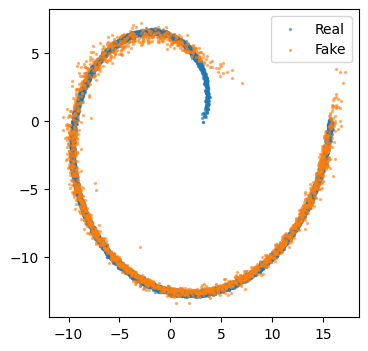

Iter 1000: loss_D=-0.0084, loss_G=2.8216


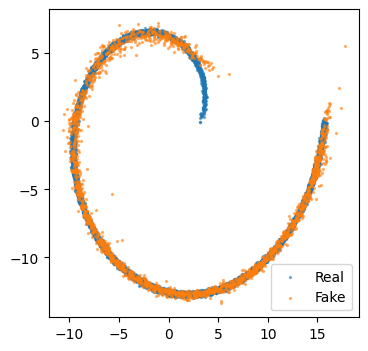

Iter 1500: loss_D=0.0034, loss_G=2.3227


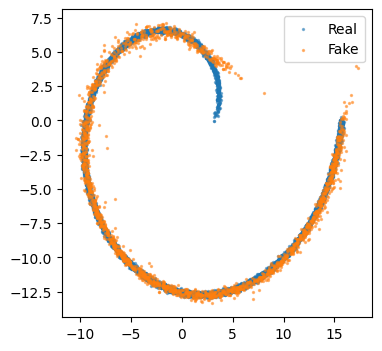

Iter 2000: loss_D=-0.0033, loss_G=2.2229


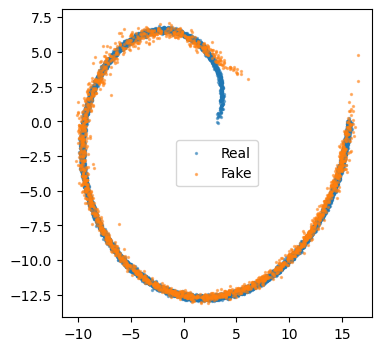

Iter 2500: loss_D=-0.1781, loss_G=2.4625


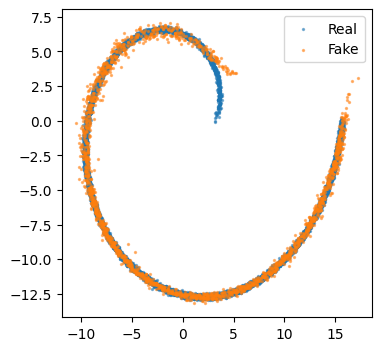

Iter 3000: loss_D=-0.0604, loss_G=2.2017


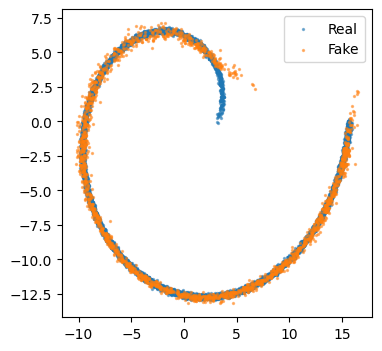

Iter 3500: loss_D=-0.0790, loss_G=2.2313


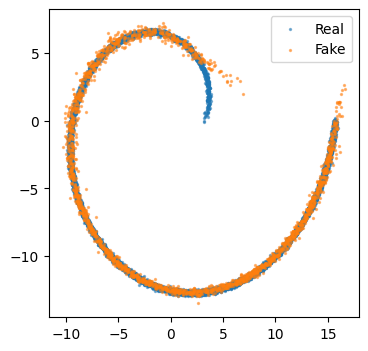

Iter 4000: loss_D=0.0176, loss_G=2.2412


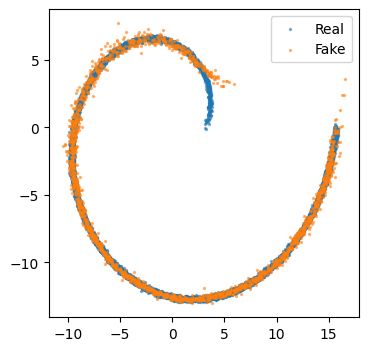

Iter 4500: loss_D=-0.0892, loss_G=1.9643


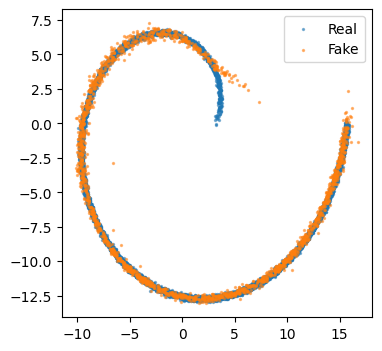

Iter 5000: loss_D=0.0173, loss_G=1.8171


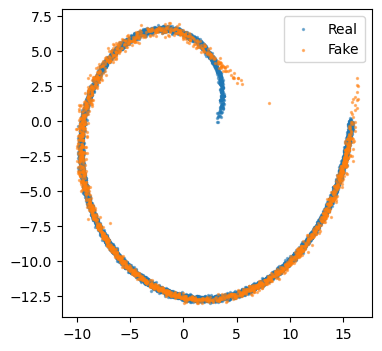

In [15]:
n_iter = 5000
dataloader_iter = cycle(dataloader)

for it in range(n_iter):
    for t in range(n_critic):
        
        x_real = next(dataloader_iter)[0].to(device)
        z = torch.randn(batch_size, latent_dim, device=device)
        eps = torch.rand(batch_size, 1, device=device)

        with torch.no_grad():
            x_fake = G(z)

        x_hat = eps * x_real + (1 - eps) * x_fake
        x_hat.requires_grad_(True)

        D_real = D(x_real)
        D_fake = D(x_fake)
        D_x_hat = D(x_hat)

        grad = torch.autograd.grad(
            outputs=D_x_hat,
            inputs=x_hat,
            grad_outputs=torch.ones_like(D_x_hat),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]

        grad_norm = grad.view(grad.size(0), -1).norm(2, dim=1)
        gp = ((grad_norm - 1) ** 2).mean()

        loss_D = D_fake.mean() - D_real.mean() + lambda_gp * gp

        D_optimizer.zero_grad()
        loss_D.backward()
        D_optimizer.step()

    
    z = torch.randn(batch_size, latent_dim, device=device)
    x_fake = G(z)
    loss_G = -D(x_fake).mean()

    G_optimizer.zero_grad()
    loss_G.backward()
    G_optimizer.step()

    
    if (it + 1) % 500 == 0:
        print(f"Iter {it+1}: loss_D={loss_D.item():.4f}, loss_G={loss_G.item():.4f}")

        # visualize generated samples
        with torch.no_grad():
            z = torch.randn(2000, latent_dim, device=device)
            samples = G(z).cpu().numpy()

        plt.figure(figsize=(4, 4))
        plt.scatter(data[:, 0], data[:, 1], s=2, label="Real", alpha=0.5)
        plt.scatter(samples[:, 0], samples[:, 1], s=2, label="Fake", alpha=0.5)
        plt.legend()
        plt.show()